In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
data = pd.read_csv('datasets/Products.csv')

In [53]:
data.shape
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4353 entries, 0 to 4352
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Prod_Desc   4353 non-null   object 
 1   Sub_Name    4353 non-null   object 
 2   Cat_Name    4353 non-null   object 
 3   ID_Proj     4353 non-null   int64  
 4   Proj_Name   4353 non-null   object 
 5   BOM_Quant   4353 non-null   float64
 6   Proj_City   4240 non-null   object 
 7   Proj_State  4275 non-null   object 
 8   Proj_Date   4353 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 306.2+ KB


,Prod_Desc,Sub_Name,Cat_Name,ID_Proj,Proj_Name,BOM_Quant,Proj_City,Proj_State,Proj_Date
0,Poste cônico continuo aço galvanizado reto fla...,Poste Metálico,Infraestrutura,10899,Poste cônico continuo aço galvanizado,1.00,Canoas,RS,2024-01-03
1,"CHUMBADOR CH2 5/8"" X 500 GALVANIZADO A FOGO",Poste Metálico,Infraestrutura,10899,Poste cônico continuo aço galvanizado,4.00,Canoas,RS,2024-01-03
2,Chapa antiderrapante ; AC SAE1010 ; padrão NBR...,Barras e tubos INOX,Ferragens,10900,Cotacao EE 24010015,16.00,Niterói,RJ,2024-01-03
3,Cantoneira de aço Cantoneira NBR 15980 L - PER...,Barras e tubos INOX,Ferragens,10900,Cotacao EE 24010015,40.00,Niterói,RJ,2024-01-03
4,Pedregulho ; lavado ; Granulometria 4 a 8mm ; ...,"Areia, Pedra Brita, Gesso, Cal e Argila",Construção Civil,10901,Cotação - PEDREGULHOS - Lic,8.05,Ipojuca,PE,2024-01-03


In [54]:
missing_values = data.isnull().sum()
duplicated_rows = data.duplicated().sum()

In [55]:
duplicated_rows, missing_values

(np.int64(182),
 Prod_Desc       0
 Sub_Name        0
 Cat_Name        0
 ID_Proj         0
 Proj_Name       0
 BOM_Quant       0
 Proj_City     113
 Proj_State     78
 Proj_Date       0
 dtype: int64)

In [56]:
data['Proj_City'].fillna('Não informado', inplace=True)
data['Proj_State'].fillna('Não informado', inplace=True)

C:\Users\celso\AppData\Local\Temp\ipykernel_28076\2389356626.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Proj_City'].fillna('Não informado', inplace=True)
C:\Users\celso\AppData\Local\Temp\ipykernel_28076\2389356626.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [57]:
top_categorias = data['Cat_Name'].value_counts().head(10)
top_subcategorias = data['Sub_Name'].value_counts().head(10)
top_cidades = data['Proj_City'].value_counts().head(10)

In [64]:
(top_categorias, top_subcategorias)

(Cat_Name
 Materiais Elétricos      826
 Ferragens                650
 Outros                   637
 Infraestrutura           554
 Construção Civil         447
 Materiais Hidráulicos    427
 Ferramentas              130
 Tintas e Acessórios      104
 Segurança do Trabalho     88
 Iluminação                77
 Name: count, dtype: int64,
 Sub_Name
 Sem Categoria                     628
 Artefatos de Concreto             180
 Ferragens para Fixar e Montar     171
 Tubos e Eletrodutos               161
 Canos e Conexões Hidráulicas      150
 Poste de Concreto                 133
 Aduela de Concreto                121
 Perfis e chapas em aço carbono    109
 Proteções Elétricas                96
 Cabos Elétricos                    95
 Name: count, dtype: int64)

In [59]:
top_cidades

Proj_City
Goiânia           528
Cuiabá            314
Porto Alegre      260
Rio de Janeiro    238
São Paulo         166
Brasília          129
Salvador          115
Não informado     113
Belo Horizonte    110
Vitória           107
Name: count, dtype: int64

In [60]:
quant_stats = data['BOM_Quant'].describe()
quant_stats

count      4353.000000
mean        724.321133
std        6064.425950
min           0.130000
25%           3.000000
50%          20.000000
75%         115.000000
max      200000.000000
Name: BOM_Quant, dtype: float64

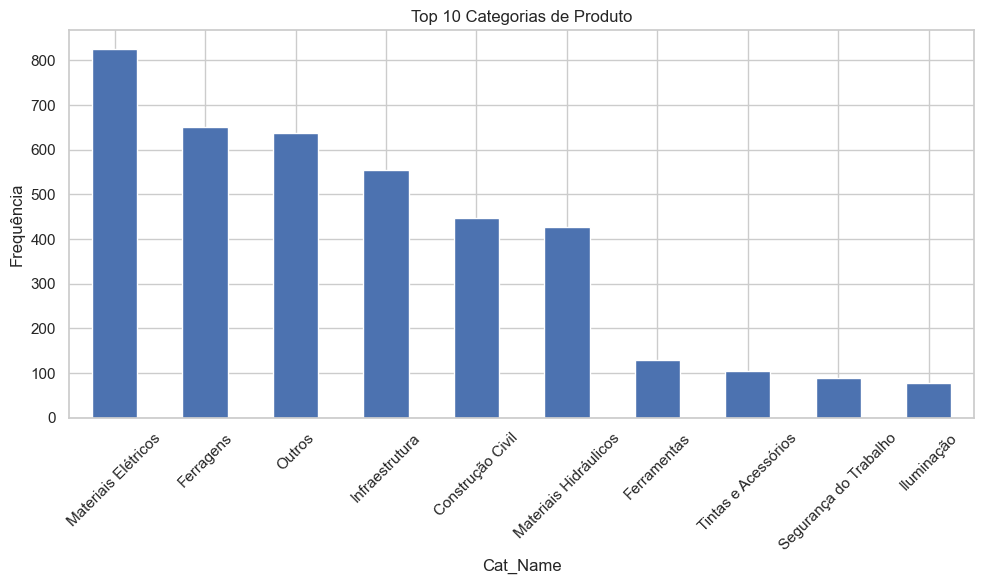

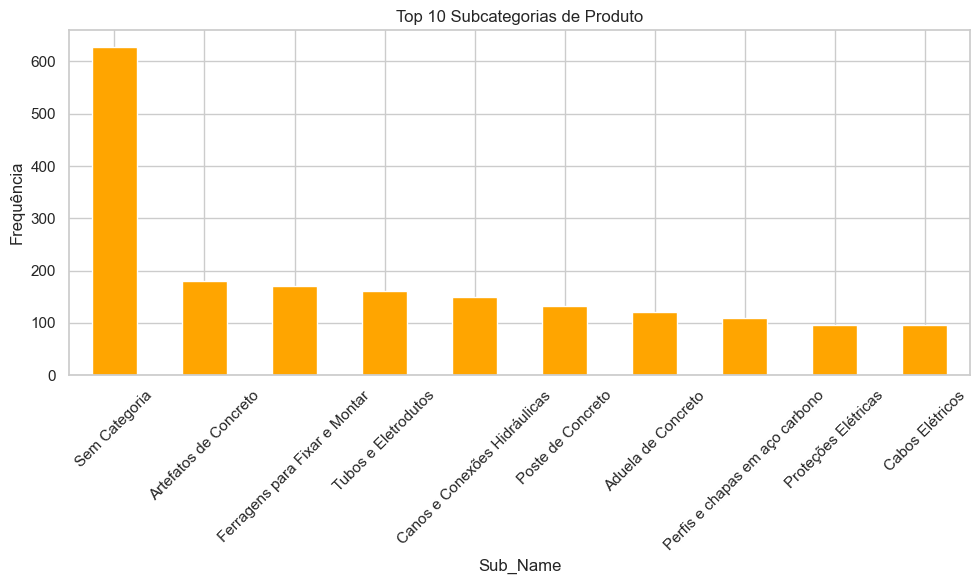

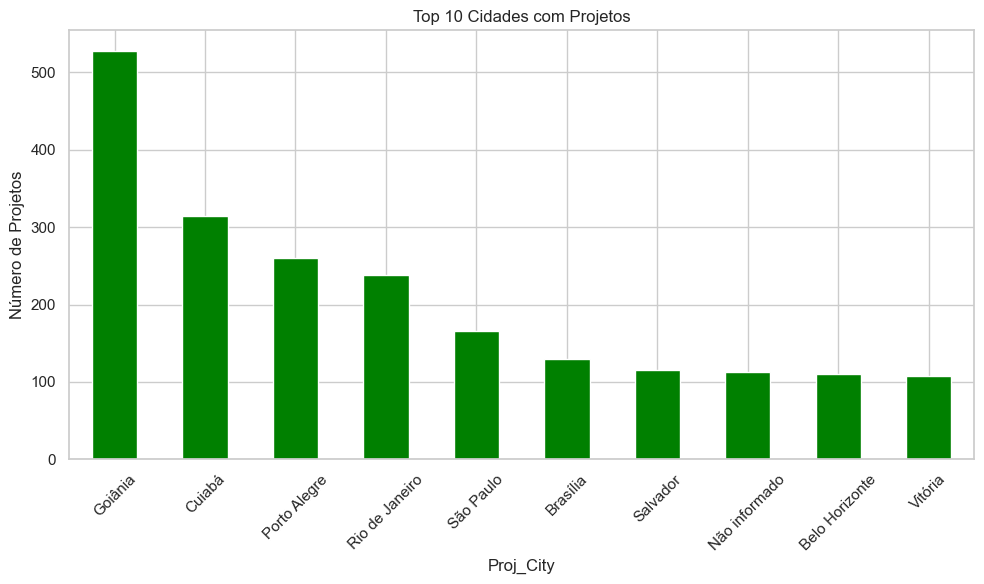

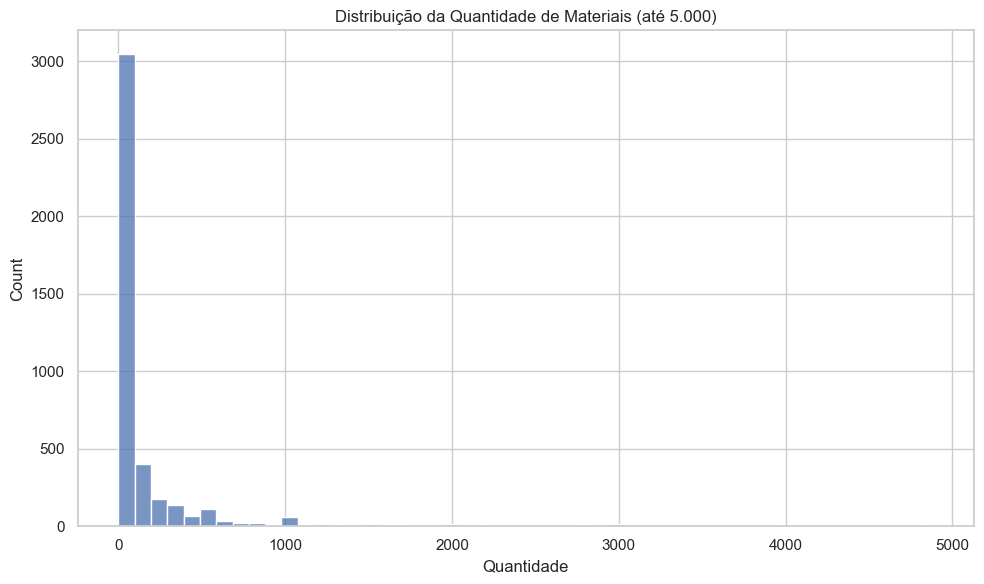

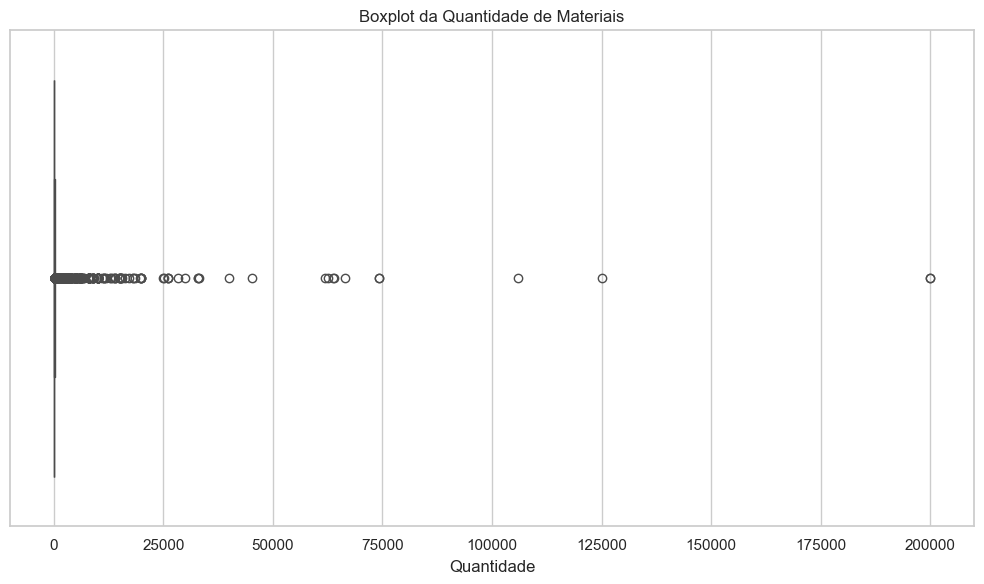

In [61]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

plt.figure()
top_categorias.plot(kind='bar')
plt.title("Top 10 Categorias de Produto")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
top_subcategorias.plot(kind='bar', color='orange')
plt.title("Top 10 Subcategorias de Produto")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
top_cidades.plot(kind='bar', color='green')
plt.title("Top 10 Cidades com Projetos")
plt.ylabel("Número de Projetos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
sns.histplot(data[data['BOM_Quant'] < 5000]['BOM_Quant'], bins=50, kde=False)
plt.title("Distribuição da Quantidade de Materiais (até 5.000)")
plt.xlabel("Quantidade")
plt.tight_layout()
plt.show()

plt.figure()
sns.boxplot(x=data['BOM_Quant'])
plt.title("Boxplot da Quantidade de Materiais")
plt.xlabel("Quantidade")
plt.tight_layout()
plt.show()

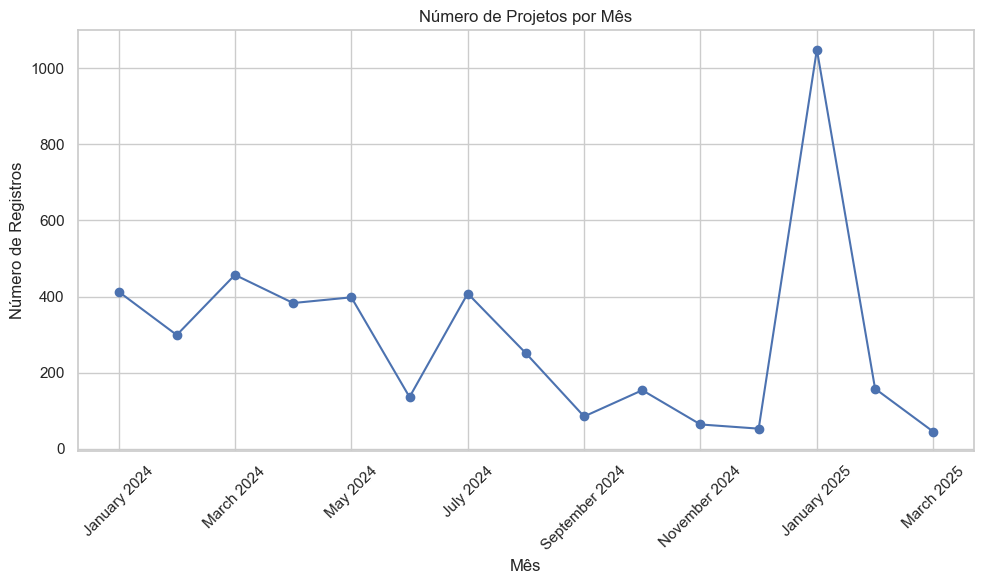

In [ ]:
data['Proj_Date'] = pd.to_datetime(data['Proj_Date'], errors='coerce')
data['Month_Name'] = data['Proj_Date'].dt.strftime('%B %Y')

projects_by_month_named = data.groupby('Month_Name').size()
projects_by_month_named.index = pd.to_datetime(projects_by_month_named.index, format='%B %Y')
projects_by_month_named = projects_by_month_named.sort_index()
projects_by_month_named.index = projects_by_month_named.index.strftime('%B %Y')

plt.figure()
projects_by_month_named.plot(marker='o')
plt.title("Número de Projetos por Mês")
plt.ylabel("Número de Registros")
plt.xlabel("Mês")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

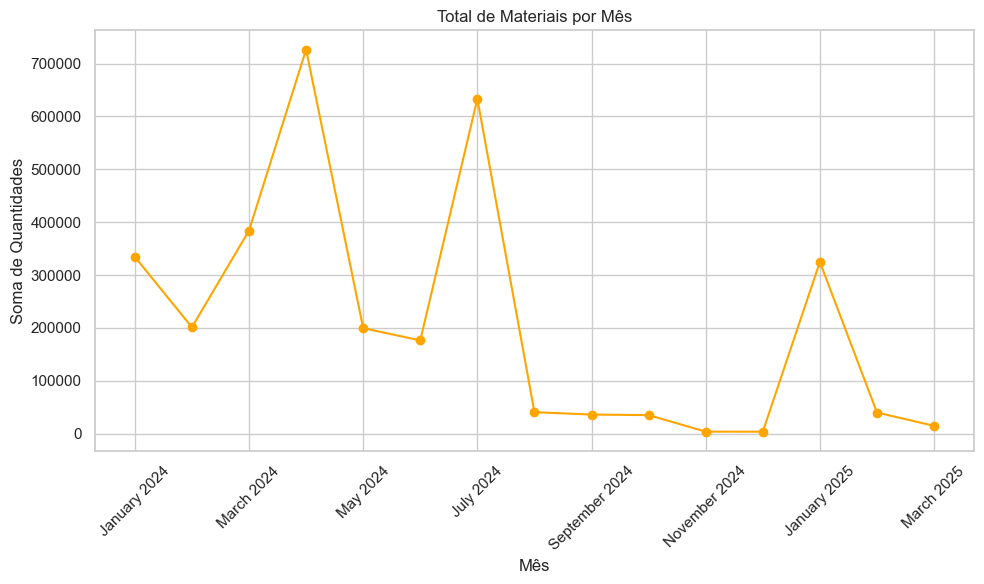

In [ ]:
quant_by_month_named = data.groupby('Month_Name')['BOM_Quant'].sum()
quant_by_month_named.index = pd.to_datetime(quant_by_month_named.index, format='%B %Y')

quant_by_month_named = quant_by_month_named.sort_index()
quant_by_month_named.index = quant_by_month_named.index.strftime('%B %Y')

plt.figure()
quant_by_month_named.plot(marker='o', color='orange')
plt.title("Total de Materiais por Mês")
plt.ylabel("Soma de Quantidades")
plt.xlabel("Mês")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\celso\AppData\Local\Temp\ipykernel_28076\3289342485.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_states['Proj_Month'] = df_top_states['Proj_Date'].dt.to_period('M')


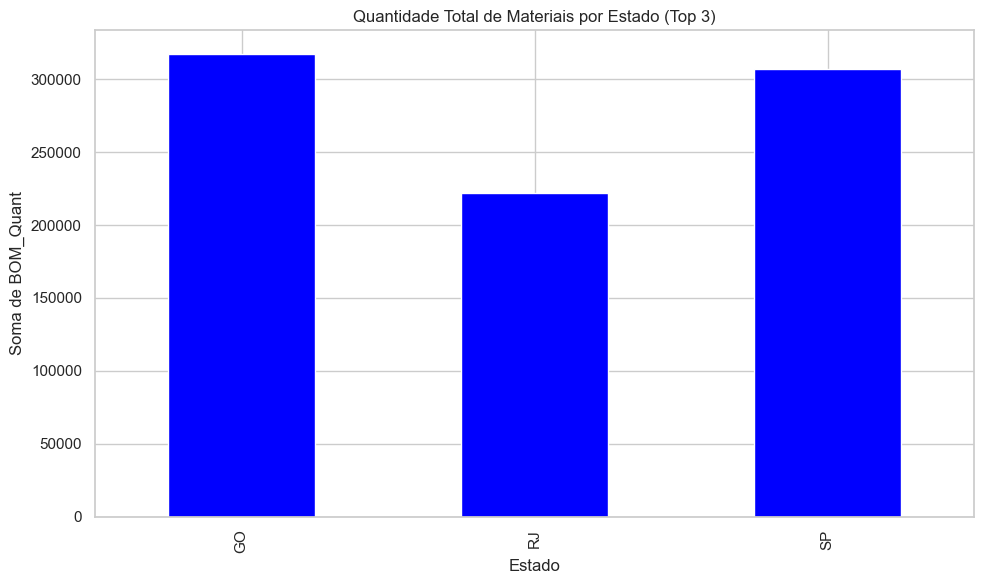

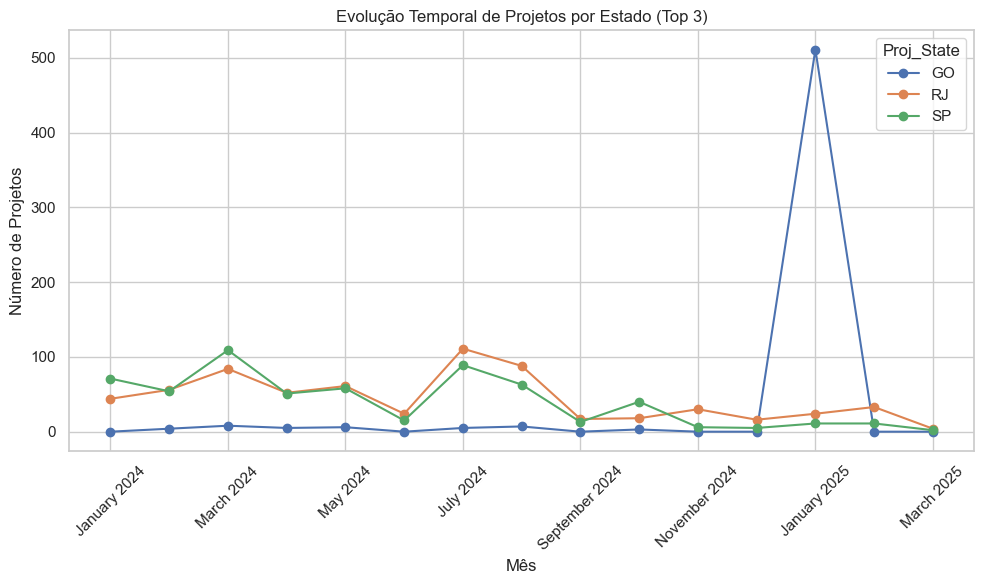

In [ ]:
df_top_states = data[data['Proj_State'].isin(['RJ', 'SP', 'GO'])]

cat_by_state = df_top_states.groupby(['Proj_State', 'Cat_Name']).size().unstack().fillna(0)

quant_by_state = df_top_states.groupby('Proj_State')['BOM_Quant'].sum()

df_top_states['Proj_Month'] = df_top_states['Proj_Date'].dt.to_period('M')

evolucao_temporal = df_top_states.groupby(['Proj_Month', 'Proj_State']).size().unstack().fillna(0)
evolucao_temporal.index = pd.PeriodIndex(evolucao_temporal.index, freq='M').to_timestamp()
evolucao_temporal.index = evolucao_temporal.index.strftime('%B %Y')

quant_by_state.plot(kind='bar', color='blue')
plt.title("Quantidade Total de Materiais por Estado (Top 3)")
plt.ylabel("Soma de BOM_Quant")
plt.xlabel("Estado")
plt.tight_layout()
plt.show()

evolucao_temporal.index = evolucao_temporal.index.astype(str) 
evolucao_temporal.plot(marker='o')
plt.title("Evolução Temporal de Projetos por Estado (Top 3)")
plt.ylabel("Número de Projetos")
plt.xlabel("Mês")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

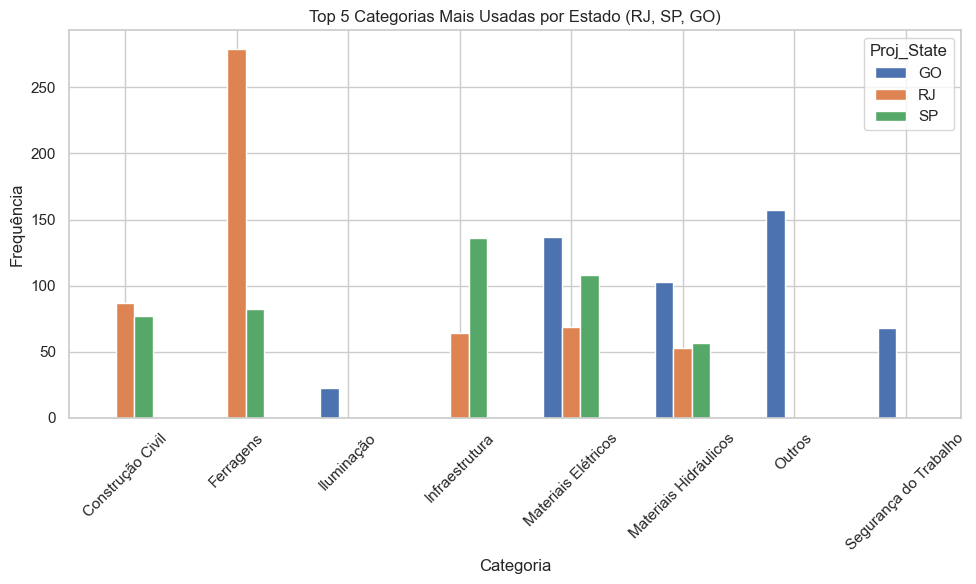

In [ ]:
top5_categorias_por_estado = (
    df_top_states.groupby(['Proj_State', 'Cat_Name']).size()
    .groupby(level=0, group_keys=False)
    .nlargest(5)
)

top5_df = top5_categorias_por_estado.reset_index(name='Frequencia')
pivot_top5 = top5_df.pivot(index='Cat_Name', columns='Proj_State', values='Frequencia').fillna(0)

pivot_top5.plot(kind='bar')
plt.title("Top 5 Categorias Mais Usadas por Estado (RJ, SP, GO)")
plt.ylabel("Frequência")
plt.xlabel("Categoria")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()